### data structure
```
MEA/
└── 1/
    ├── rns_20250414_29679-1.raw.h5         # raw MaxWell recording
    ├── lfp/
    │   └── recording.zarr/                 # band-passed + downsampled MaxWell recording (not used)
    ├── spike/
    │   ├── mx_output_refined/
    │   │   └── firings.npz                 # MaxWell on-chip threshold detector (not used)
    │   ├── sorter_output/
    │   │   └── firings.npz                 # MountainSort5 output
    │   ├── sorter_output_refined/
    │   │   └── firings.npz                 # curated MountainSort5 output
    │   ├── sorting_analyzer.zarr/          # templates, unit positions
    │   ├── data_refined.npy                # per-spike table behind spike_map.png
    │   ├── data_refined_mx.npy             # same columns for the on-chip detector
    │   ├── spike_map.png                   # units X array figure
    │   ├── spikeinterface_log.json         # sorter version and run time
    │   ├── spikeinterface_params.json      # sorter parameters
    │   └── spikeinterface_recording.json   # metadata
    ├── probe_map.png                       # electrode layout with channel numbers
    └── file_list.npy                       # original path? (not used)
```

### probe_map.png

![](img/probe_map.png)  

https://pmc.ncbi.nlm.nih.gov/articles/PMC8900719/

"An almost arbitrary combination of up to 1,024 electrodes and be recorded from simultaneously" (881 green dots)

### spike_map.png

![](img/spike_map.png)

In [1]:
import os
import h5py
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import spikeinterface.full as si
from pathlib import Path

/Users/bryanzheng/.venvs/glioma-mea/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
h5py.h5pl.prepend(str(Path.home() / "hdf5_plugin_path_maxwell").encode())
os.environ["HDF5_PLUGIN_PATH"] = str(Path.home() / "hdf5_plugin_path_maxwell")

In [3]:
# paths
DATA_DIR = Path("/Users/bryanzheng/Library/CloudStorage/GoogleDrive-bzheng112@gmail.com/My Drive/data/MEA/1")
SORTING_NPZ = DATA_DIR / "spike" / "sorter_output_refined" / "firings.npz"
ANALYZER_DIR = DATA_DIR / "spike" / "sorting_analyzer.zarr"
RAW_H5 = DATA_DIR / "rns_20250414_29679-1.raw.h5"

In [4]:
rec = si.read_maxwell(RAW_H5)
fs = rec.sampling_frequency
n_samples = rec.get_num_samples()
duration = n_samples / fs
n_channels = rec.get_num_channels()

In [5]:
print("length (number of samples) = {:.0f}".format(n_samples))
print("sampling frequency = {:.0f} Hz".format(fs))
print("duration = {:.0f}".format(duration))
print("number of channels = {:.0f}".format(n_channels))

length (number of samples) = 6001800
sampling frequency = 20000 Hz
duration = 300
number of channels = 881


In [6]:
step = 100 # downsampling
channel = "81"
t_start, t_end = 33.0, 35.0

In [7]:
z = rec.get_traces(start_frame=int(t_start*fs), 
                   end_frame=int(t_end*fs),
                   channel_ids=[channel],
                   return_scaled=True)[::step,0]
z = z - np.median(z) # remove baseline
t = t_start + np.arange(z.size) * step / fs

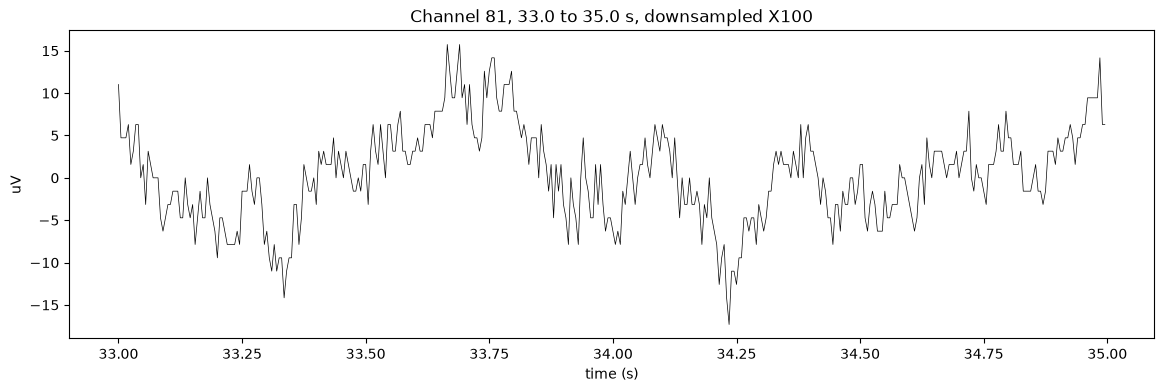

In [8]:
fig, ax = plt.subplots(figsize=(14,4))
ax.plot(t, z, color="k", lw=0.5)
ax.set(xlabel="time (s)", ylabel="uV", title=f"Channel {channel}, {t_start} to {t_end} s, downsampled X{step}")
plt.show()

### spike sorting

MountainSort:  
https://www.sciencedirect.com/science/article/pii/S0896627317307456  
https://github.com/flatironinstitute/mountainlab-js  
https://github.com/flatironinstitute/mountainsort5  

In [9]:
detect_sign = -1 # default

In [10]:
SORT_DIR = Path.home() / "Downloads" / f"ms5_sign{detect_sign}_full"

In [11]:
rec_in = si.center(si.scale_to_uV(si.unsigned_to_signed(rec)), mode="median")

In [12]:
params = dict(scheme="2", detect_sign=detect_sign, detect_threshold=5.5,
              snippet_T2=40, snippet_mask_radius=50,
              scheme2_training_duration_sec=60,
              filter=True, whiten=True, n_jobs=1)   

In [13]:
#https://spikeinterface.readthedocs.io/en/stable/modules/sorters.html
sorting_new = si.run_sorter("mountainsort5", 
                            rec_in,
                            folder=SORT_DIR,
                            remove_existing_folder=True,
                            verbose=False, 
                            **params)

filtering
whitening
write_binary_recording 
engine=process - n_jobs=1 - samples_per_chunk=20,000 - chunk_memory=67.21 MiB - total_memory=67.21 MiB - chunk_duration=1.00s


write_binary_recording (no parallelization): 100%|████████████████████████████| 301/301 [04:36<00:00,  1.09it/s]


Using training recording of duration 60 sec with the sampling mode uniform
*** MS5 Elapsed time for SCHEME2 get_sampled_recording_for_training: 21.182 seconds ***
Running phase 1 sorting
Number of channels: 881
Number of timepoints: 1200000
Sampling frequency: 20000.0 Hz
Channel 0: [ 70.  612.5]
Channel 1: [ 962.5 1802.5]
Channel 2: [   0. 1050.]
Channel 3: [1155. 1435.]
Channel 4: [   0. 1015.]
Channel 5: [1050. 1505.]
Channel 6: [ 122.5 1347.5]
Channel 7: [1015.  1137.5]
Channel 8: [  17.5 1032.5]
Channel 9: [ 682.5 1050. ]
Channel 10: [  35. 1050.]
Channel 11: [ 385.  1592.5]
Channel 12: [  0. 980.]
Channel 13: [ 910.  1067.5]
Channel 14: [  17.5 1085. ]
Channel 15: [1032.5  927.5]
Channel 16: [192.5 980. ]
Channel 17: [1102.5 1050. ]
Channel 18: [  17.5 1102.5]
Channel 19: [ 945.  1172.5]
Channel 20: [ 70. 980.]
Channel 21: [1032.5 1452.5]
Channel 22: [  87.5 1207.5]
Channel 23: [ 350.  1627.5]
Channel 24: [ 17.5 962.5]
Channel 25: [ 630. 1785.]
Channel 26: [  35.  1242.5]
Channel 

In [14]:
print(sorting_new)
print("units:", sorting_new.get_num_units(), "| spikes:", sorting_new.to_spike_vector().size)

NpzSortingExtractor: 34 units - 1 segments - 20.0kHz
  file_path: /Users/bryanzheng/Downloads/ms5_sign-1_full/sorter_output/firings.npz
units: 34 | spikes: 6817


In [17]:
analyzer = si.create_sorting_analyzer(sorting_new, rec_in, sparse=True, n_jobs=1)
analyzer.compute(["random_spikes", "waveforms", "templates", "unit_locations"], n_jobs=1)
xy = analyzer.get_extension("unit_locations").get_data()[:,:2]

compute_waveforms (no parallelization): 100%|█████████████████████████████████| 301/301 [00:43<00:00,  6.89it/s]


In [103]:
print(xy.shape, "| x range", xy[:, 0].min().round(), xy[:, 0].max().round(), "| y range", xy[:, 1].min().round(), xy[:, 1].max().round())

(34, 2) | x range 14.0 1229.0 | y range 485.0 2454.0


In [104]:
analyzer.compute("template_similarity")                      # cosine similarity of the average waveforms, per pair of units
sim = analyzer.get_extension("template_similarity").get_data()
sim_ids = list(analyzer.unit_ids)
def template_sim(a, b):
    """cosine similarity of the templates of units a and b: ~1 same waveform, ~0 unrelated"""
    return float(sim[sim_ids.index(a), sim_ids.index(b)])
print("templates available for", len(sim_ids), "units")

templates available for 34 units


In [105]:
units = list(sorting_new.unit_ids)
spike_times={u: sorting_new.get_unit_spike_train(u) / fs for u in units}
rate = np.array([len(spike_times[u]) / duration for u in units])
xy_unit = {u: xy[k] for k, u in enumerate(sorting_new.unit_ids)}   # position by unit id
xy_units = np.array([xy_unit[u] for u in units])                    # positions in the order of `units`

In [106]:
elec = rec.get_channel_locations()

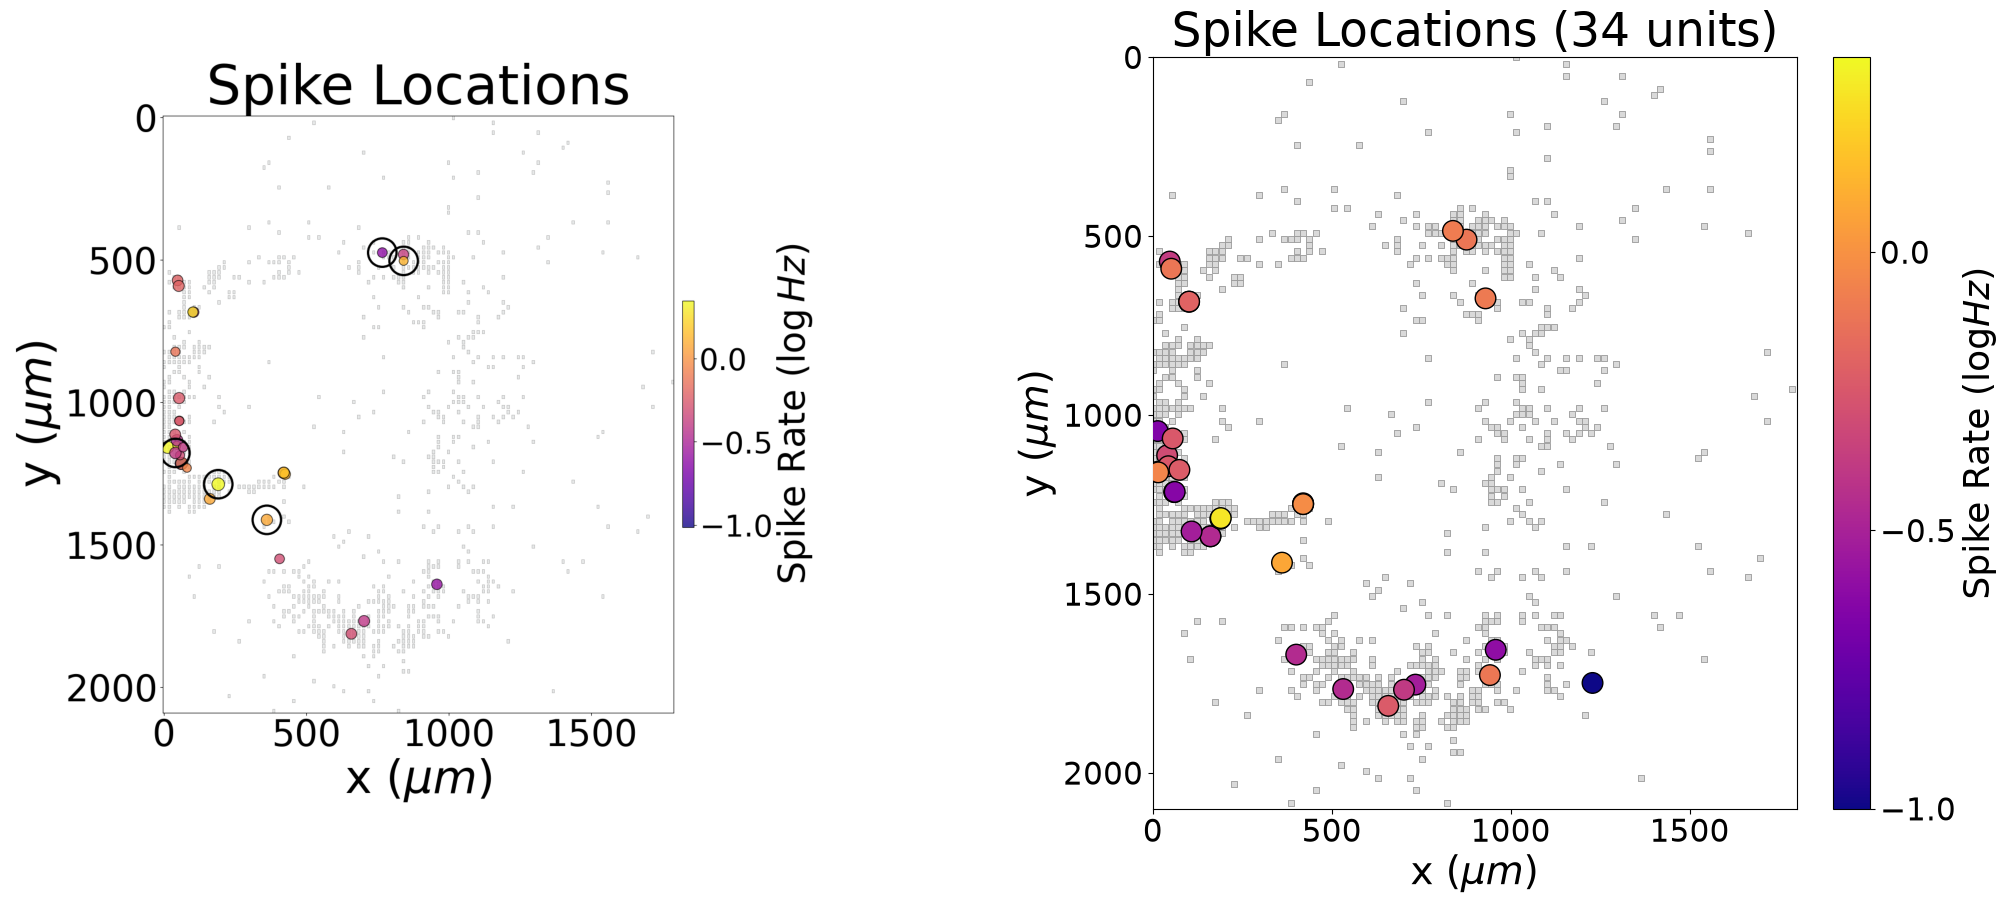

In [107]:
plt.rcParams.update({"font.size": 22})
img = plt.imread(DATA_DIR / "spike" / "spike_map.png")
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(21, 9.5))

ax0.imshow(img)
ax0.axis("off")

ax1.scatter(elec[:, 0], elec[:, 1], s=18, marker="s", facecolor="0.85", edgecolor="0.6", linewidth=0.6)
sc = ax1.scatter(xy_units[:, 0], xy_units[:, 1], c=np.log10(rate), cmap="plasma", s=220, edgecolor="k", linewidth=1.0,
                 vmin=-1.0, vmax=0.35, zorder=3)
cb = fig.colorbar(sc, ax=ax1, fraction=0.046, pad=0.04)
cb.set_label(r"Spike Rate (log$Hz$)", fontsize=26)
cb.set_ticks([-1.0, -0.5, 0.0])
ax1.set(xlim=(0, 1800), ylim=(2100, 0), aspect="equal")
ax1.set_xticks([0, 500, 1000, 1500])
ax1.set_yticks([0, 500, 1000, 1500, 2000])
ax1.set_xlabel(r"x ($\mu m$)", fontsize=28)
ax1.set_ylabel(r"y ($\mu m$)", fontsize=28)
ax1.set_title(f"Spike Locations ({len(units)} units)", fontsize=34)
fig.tight_layout()
plt.show()

### prelim figure

![](img/network.png)

1. raster plots - cortex-ganglionic eminence (Cx+GE) control (iCtrl) vs mutated (Mut) organoid
2. 31 x 31 functional connectivity matrix
3. constructed network with summary statistics + 3/4-node motif analysis
4. stimulation panel (100 ms train at 200 Hz; response amplitude and PD).

### raster

In [108]:
x = np.concatenate([spike_times[u] for u in units])
y = np.concatenate([np.full(len(spike_times[u]), k + 1) for k, u in enumerate(units)])

points: 6817


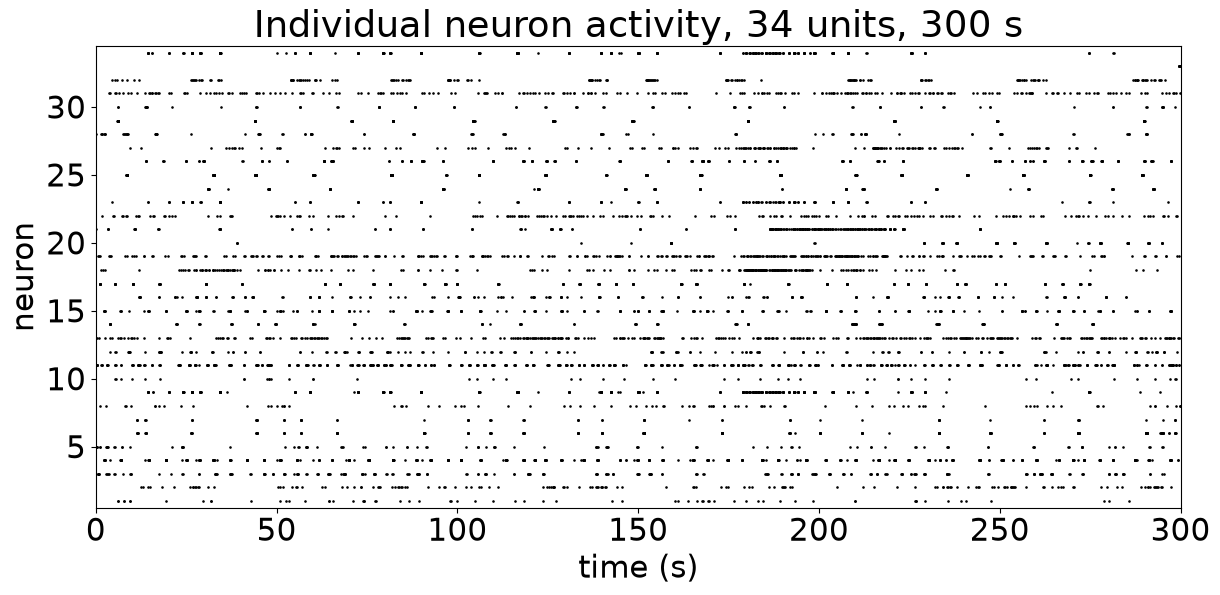

In [109]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.scatter(x, y, s=3, c="k", marker=".")
ax.set(xlim=(0, duration), ylim=(0.5, len(units) + 0.5), xlabel="time (s)", ylabel="neuron", title=f"Individual neuron activity, {len(units)} units, {duration:.0f} s")
print("points:", x.size)
plt.show()

### functional connectivity

In [110]:
def fraction_within(ta, tb, w):
    """ fraction of spikes in ta with a spike in tb within +/- w seconds (both sorted)"""
    j = np.clip(np.searchsorted(tb, ta), 1, len(tb)-1)
    d = np.minimum(np.abs(tb[j] - ta), np.abs(tb[j -1] - ta))
    return (d <= w).mean()

In [111]:
def crosscorrelogram(ta, tb, max_lag=0.05, bin_s=0.001):
    """counts of tb spikes at each lag relative to every ta spike"""
    lags = np.concatenate([tb[(tb > t - max_lag) & (tb < t + max_lag)] - t for t in ta])
    bins = np.arange(-max_lag, max_lag + bin_s, bin_s)
    return np.histogram(lags, bins)[0], (bins[:-1] + bins[1:]) / 2 * 1000

In [112]:
rows = []
for i in range(len(units)):
    for j in range(i + 1, len(units)):
        a, b = units[i], units[j]
        small, big = sorted((spike_times[a], spike_times[b]), key=len)
        f2 = fraction_within(small, big, 0.002)
        if f2 > 0.1:
            rows.append(dict(unit_a=a, unit_b=b, n_small=len(small),
                             f_05ms=round(fraction_within(small, big, 0.0005), 3),
                             f_2ms=round(f2, 3),
                             dist_um=round(np.hypot(*(xy_unit[a] - xy_unit[b]))),
                             template_sim=round(template_sim(a, b), 2)))
suspects = pd.DataFrame(rows).sort_values("f_2ms", ascending=False).reset_index(drop=True)

In [113]:
suspects

,unit_a,unit_b,n_small,f_05ms,f_2ms,dist_um,template_sim
0,10,35,285,0.063,0.853,0,0.49
1,10,24,153,0.438,0.830,2,0.49
2,24,35,153,0.614,0.614,2,0.87
3,5,16,270,0.167,0.167,2,0.89
4,11,12,49,0.122,0.122,2,0.87
5,13,17,172,0.110,0.110,33,0.02


In [114]:
# second criterion: a pair whose cross-correlogram has >= 30 counts in the 6-30 ms flanks but < 25% of the
# expected counts in the 1.5-6 ms band shares a refractory period, ie is one neuron split in two (burst split)
rows = []
for i in range(len(units)):
    for j in range(i + 1, len(units)):
        a, b = units[i], units[j]
        h, lag = crosscorrelogram(spike_times[a], spike_times[b])
        gap = h[(np.abs(lag) > 1.5) & (np.abs(lag) <= 6)].sum()
        flank = h[(np.abs(lag) > 6) & (np.abs(lag) <= 30)].sum()
        expected = flank * 9 / 48                       # 9 ms of gap bins, 48 ms of flank bins
        if flank >= 30 and gap < 0.25 * expected:
            rows.append(dict(unit_a=a, unit_b=b, gap=gap, flank=flank, expected_gap=round(expected, 1),
                             dist_um=round(np.hypot(*(xy_unit[a] - xy_unit[b]))),
                             template_sim=round(template_sim(a, b), 2)))
refractory_splits = pd.DataFrame(rows)

In [115]:
refractory_splits

,unit_a,unit_b,gap,flank,expected_gap,dist_um,template_sim
0,5,16,1,265,49.7,2,0.89
1,7,8,0,170,31.9,2,0.81
2,10,24,0,401,75.2,2,0.49
3,10,35,0,779,146.1,0,0.49
4,24,35,0,340,63.8,2,0.87


In [116]:
thresh = 0.1      # coincidence rule: > 10% of the smaller unit's spikes within 2 ms of the other AND a shared waveform (template_sim > 0.5)
min_sim = 0.5     # refractory rule (refractory_splits) needs no waveform condition: the phase-offset re-detections have sim ~0.4
pairs = (suspects.loc[(suspects.f_2ms > thresh) & (suspects.template_sim > min_sim), ["unit_a", "unit_b"]].values.tolist()
         + refractory_splits[["unit_a", "unit_b"]].values.tolist())
groups = [sorted(g, key=lambda u: -len(spike_times[u])) for g in nx.connected_components(nx.Graph(pairs))]
duplicates = {g[0]: g[1:] for g in groups}

In [117]:
duplicates

{10: [35, 24], 5: [16], 12: [11], 7: [8]}

In [118]:
for keep, absorbed in duplicates.items():
    t = np.sort(np.concatenate([spike_times[keep]] + [spike_times.pop(u) for u in absorbed]))
    spike_times[keep] = t[np.r_[True, np.diff(t) >= 0.001]]
units = sorted(spike_times)
rate = np.array([len(spike_times[u]) / duration for u in units])
xy_units = np.array([xy_unit[u] for u in units])

In [119]:
print(len(units), "units,", sum(len(t) for t in spike_times.values()), "spikes")

29 units, 6371 spikes


In [120]:
bin_s = 0.025   # 25 ms bins
edges = np.arange(0, duration + bin_s, bin_s)
counts = np.array([np.histogram(spike_times[u], edges)[0] for u in units])
C = np.corrcoef(counts)
np.fill_diagonal(C, 0)
n = len(units)
iu = np.triu_indices(n, 1)
print("bins:", counts.shape[1], "| spikes binned:", counts.sum())
top = np.argsort(C[iu])[-5:][::-1]

bins: 12004 | spikes binned: 6371


In [121]:
rng = np.random.default_rng(0)
n_shift = 1000
n_bins = counts.shape[1]
null = np.empty((n_shift, len(iu[0])))
for k in range(n_shift):
    shifted = np.array([np.roll(row, rng.integers(100, n_bins - 100)) for row in counts])
    null[k] = np.corrcoef(shifted)[iu]
thresh_r = np.percentile(np.abs(null), 99.9, axis=0)
sig = np.abs(C[iu]) > thresh_r
print("null |r| 99.9th percentile, typical: {:.3f} | significant pairs: {} of {} | expected by chance: {:.1f}".format(np.median(thresh_r), sig.sum(), sig.size, 0.001 * sig.size))
pd.DataFrame([(units[iu[0][k]], units[iu[1][k]], round(C[iu][k], 3), round(thresh_r[k], 3)) for k in np.where(sig)[0]],
             columns=["unit_a", "unit_b", "r", "threshold"])

null |r| 99.9th percentile, typical: 0.038 | significant pairs: 6 of 406 | expected by chance: 0.4


,unit_a,unit_b,r,threshold
0,3,18,0.034,0.034
1,7,31,0.077,0.057
2,9,34,0.074,0.048
3,10,32,0.044,0.034
4,13,17,0.095,0.031
5,19,20,0.049,0.042


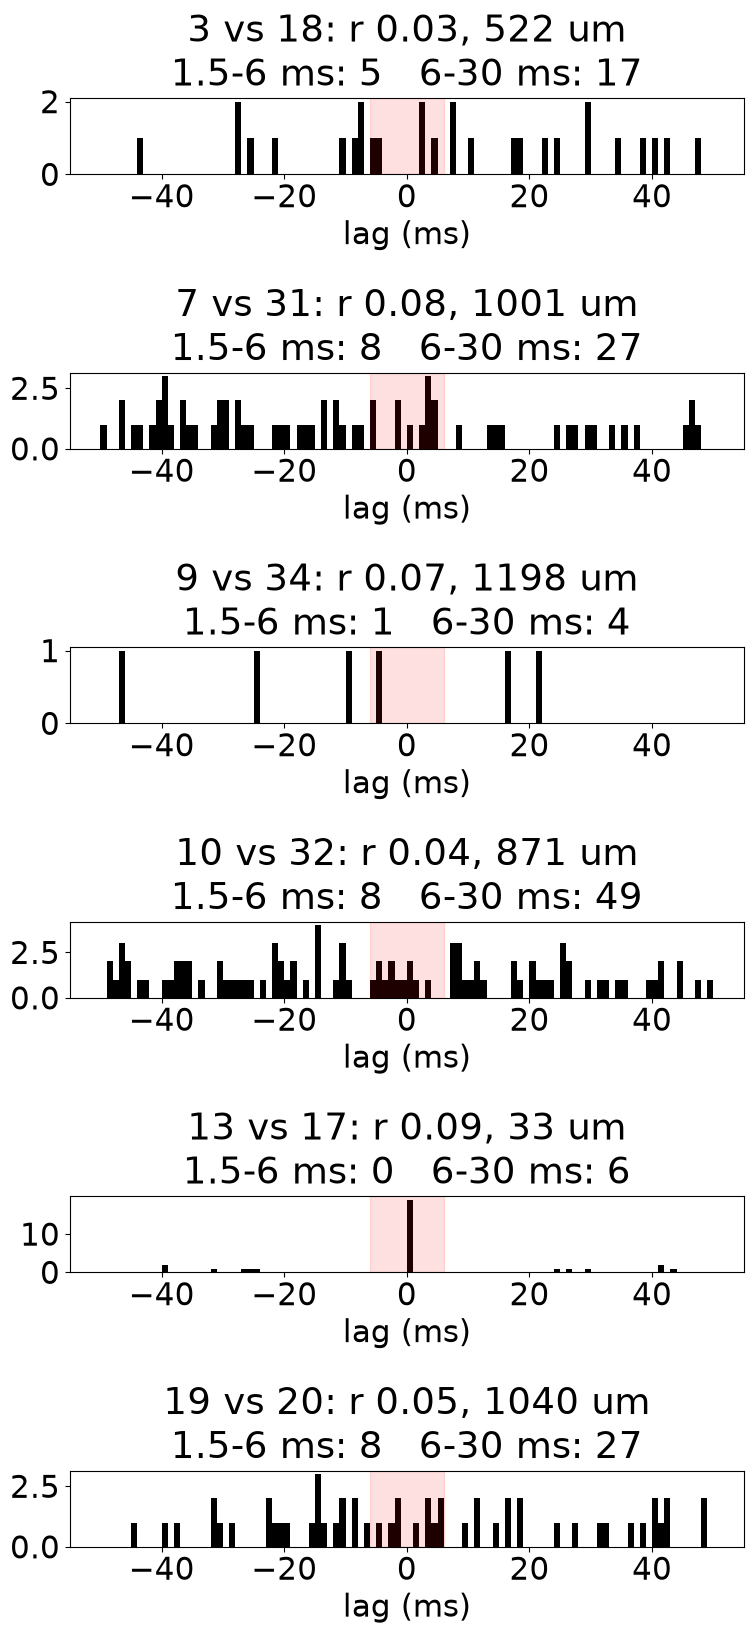

In [122]:
sig_pairs = [(units[iu[0][k]], units[iu[1][k]]) for k in np.where(sig)[0]]
fig, axs = plt.subplots(len(sig_pairs), 1, figsize=(8, 2.8 * len(sig_pairs)))
for ax, (a, b) in zip(np.atleast_1d(axs), sig_pairs):
    h, lag_ms = crosscorrelogram(spike_times[a], spike_times[b])
    ax.bar(lag_ms, h, width=1, color="k")
    ax.axvspan(-6, 6, color="red", alpha=0.12)
    gap = h[(np.abs(lag_ms) > 1.5) & (np.abs(lag_ms) <= 6)].sum()
    flank = h[(np.abs(lag_ms) > 6) & (np.abs(lag_ms) <= 30)].sum()
    ax.set(title=f"{a} vs {b}: r {C[units.index(a), units.index(b)]:.2f}, {np.hypot(*(xy_unit[a] - xy_unit[b])):.0f} um\n1.5-6 ms: {gap}   6-30 ms: {flank}", xlabel="lag (ms)")
fig.tight_layout()
plt.show()

In [123]:
mask = np.tril(np.ones_like(C, dtype=bool))          # hide the lower triangle and the diagonal
C_half = np.ma.array(C, mask=mask)

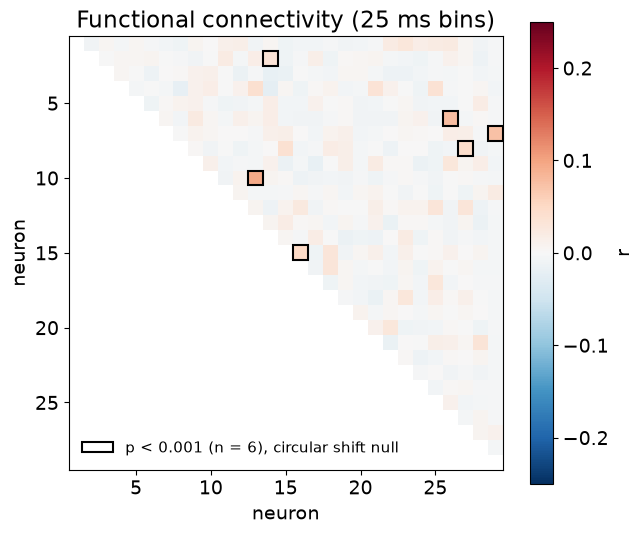

In [124]:
plt.rcParams.update({"font.size": 14})
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(C_half, cmap="RdBu_r", vmin=-0.25, vmax=0.25, extent=(0.5, n + 0.5, n + 0.5, 0.5))
for m, k in enumerate(np.where(sig)[0]):
    i, j = iu[0][k], iu[1][k]
    ax.add_patch(plt.Rectangle((j + 0.5, i + 0.5), 1, 1, fill=False, edgecolor="k", linewidth=1.5,
                               label=f"p < 0.001 (n = {sig.sum()}), circular shift null" if m == 0 else None))
fig.colorbar(im, ax=ax, label="r")
ax.legend(loc="lower left", frameon=False, fontsize=11)
ax.set(xlabel="neuron", ylabel="neuron", title=f"Functional connectivity ({int(bin_s * 1000)} ms bins)")
plt.show()

### networks

In [125]:
W_sig = np.zeros_like(C)
for k in np.where(sig)[0]:
    W_sig[iu[0][k], iu[1][k]] = W_sig[iu[1][k], iu[0][k]] = C[iu][k]
G = nx.relabel_nodes(nx.from_numpy_array(W_sig), dict(enumerate(units)))     # nodes are unit ids, edge weight is r
print("nodes:", G.number_of_nodes(), "| edges:", G.number_of_edges(), "| isolated nodes:", sum(1 for u in G if G.degree(u) == 0))

nodes: 29 | edges: 6 | isolated nodes: 17


In [126]:
pos = {u: xy_unit[u] for u in units}
edge_colors = ["red" if G[u][v]["weight"] > 0 else "blue" for u, v in G.edges]
edge_widths = [1 + 20 * abs(G[u][v]["weight"]) for u, v in G.edges]

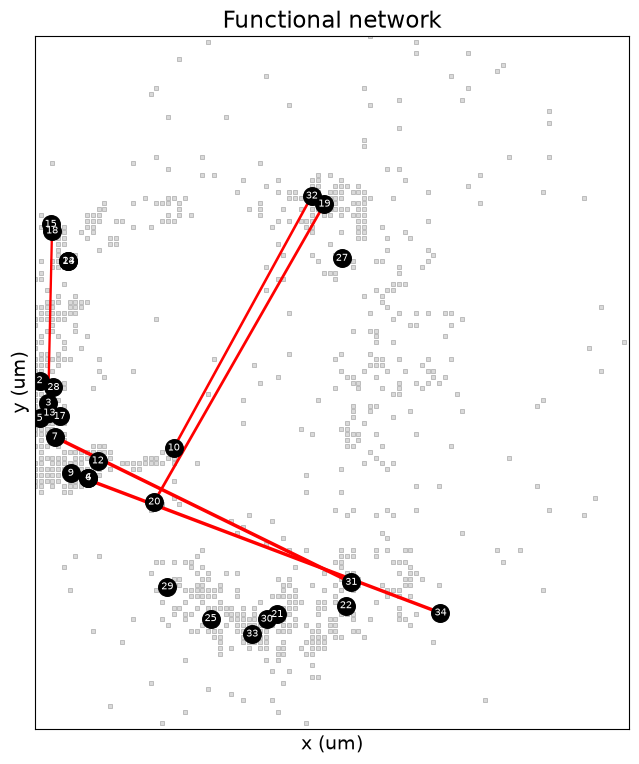

In [127]:
plt.rcParams.update({"font.size": 14})
fig, ax = plt.subplots(figsize=(8, 9))
ax.scatter(elec[:, 0], elec[:, 1], s=6, marker="s", facecolor="0.85", edgecolor="0.6", linewidth=0.4)
nx.draw_networkx(G, pos, ax=ax, node_size=160, node_color="k", font_color="w", font_size=7, edge_color=edge_colors, width=edge_widths)
ax.set(xlim=(0, 1800), ylim=(2100, 0), aspect="equal", xlabel="x (um)", ylabel="y (um)",
       title=f"Functional network")
plt.show()

### summary stats + motif "analysis"

In [130]:
deg = dict(G.degree)
triangles = sum(nx.triangles(G).values()) // 3
open_triads = sum(d * (d - 1) // 2 for d in deg.values()) - 3 * triangles
comps = sorted((len(c) for c in nx.connected_components(G)), reverse=True)
stats = [("nodes", G.number_of_nodes()),
         ("edges", G.number_of_edges()),
         ("density", f"{nx.density(G):.4f}"),
         ("mean degree", f"{np.mean(list(deg.values())):.2f}"),
         ("max degree", max(deg.values())),
         ("isolated nodes", sum(d == 0 for d in deg.values())),
         ("connected pairs or larger", sum(c >= 2 for c in comps)),
         ("largest component", comps[0]),
         ("clustering coefficient", f"{nx.average_clustering(G):.3f}"),
         ("3-node motifs, triangles", triangles),
         ("3-node motifs, open triads", open_triads)]
pd.DataFrame(stats, columns=["metric", "value"]).set_index("metric")

,value
metric,
nodes,29
edges,6
density,0.0148
mean degree,0.41
max degree,1
isolated nodes,17
connected pairs or larger,6
largest component,2
clustering coefficient,0.000


In [131]:
x = np.concatenate([spike_times[u] for u in units])
y = np.concatenate([np.full(len(spike_times[u]), k + 1) for k, u in enumerate(units)])

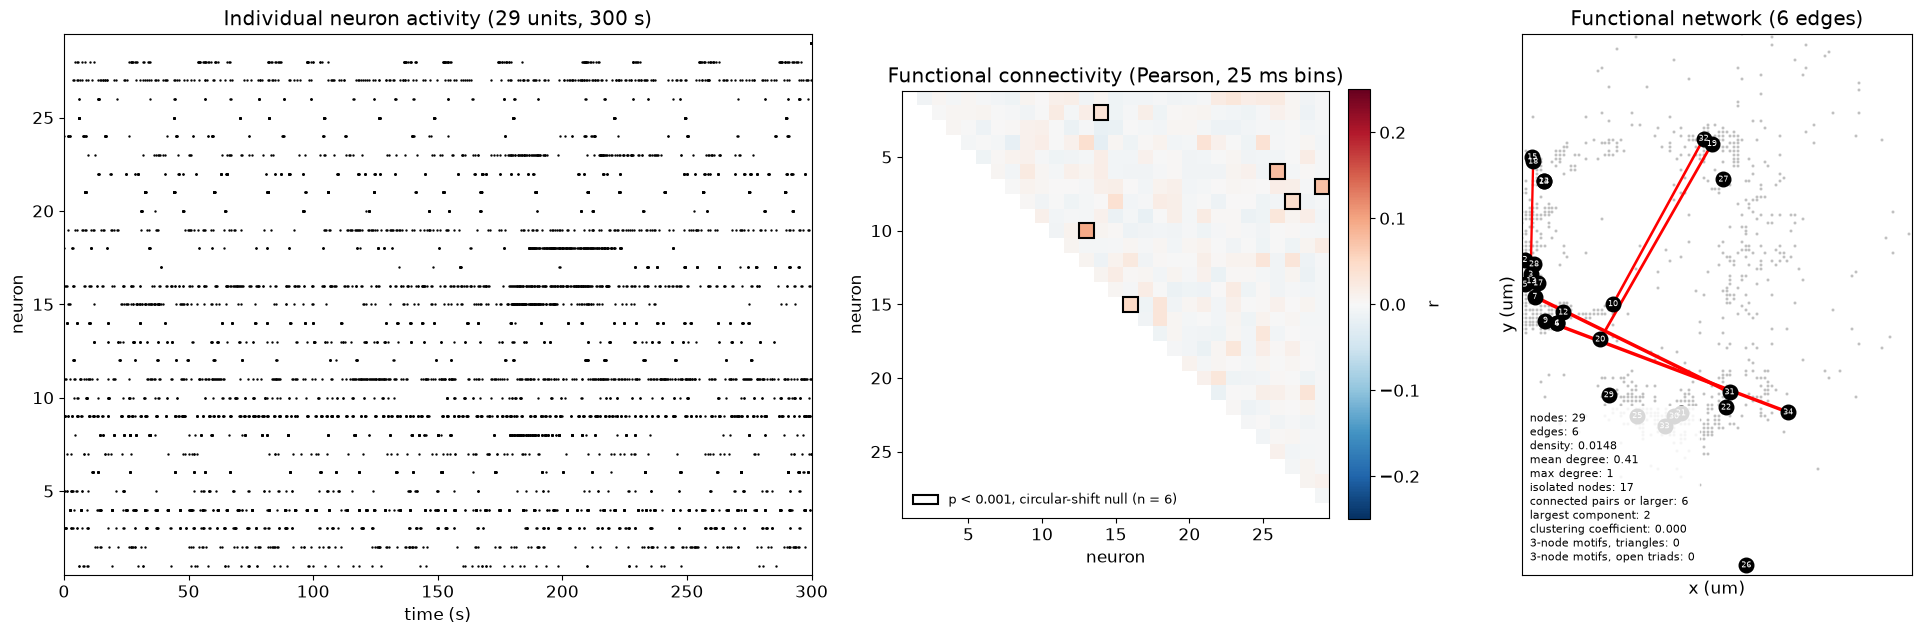

In [133]:
plt.rcParams.update({"font.size": 12})
fig, axs = plt.subplots(1, 3, figsize=(20, 6.5), gridspec_kw=dict(width_ratios=[1.6, 1, 1.1]))

axs[0].scatter(x, y, s=2, c="k", marker=".")
axs[0].set(xlim=(0, duration), ylim=(0.5, n + 0.5), xlabel="time (s)", ylabel="neuron",
           title=f"Individual neuron activity ({n} units, {duration:.0f} s)")

im = axs[1].imshow(C_half, cmap="RdBu_r", vmin=-0.25, vmax=0.25, extent=(0.5, n + 0.5, n + 0.5, 0.5))
for m, k in enumerate(np.where(sig)[0]):
    i, j = iu[0][k], iu[1][k]
    axs[1].add_patch(plt.Rectangle((j + 0.5, i + 0.5), 1, 1, fill=False, edgecolor="k", linewidth=1.5,
                                   label=f"p < 0.001, circular-shift null (n = {sig.sum()})" if m == 0 else None))
fig.colorbar(im, ax=axs[1], fraction=0.046, pad=0.04, label="r")
axs[1].legend(loc="lower left", frameon=False, fontsize=9)
axs[1].set(xlabel="neuron", ylabel="neuron", title=f"Functional connectivity (Pearson, {int(bin_s * 1000)} ms bins)")

axs[2].scatter(elec[:, 0], elec[:, 1], s=4, marker="s", facecolor="0.85", edgecolor="0.6", linewidth=0.3)
nx.draw_networkx(G, pos, ax=axs[2], node_size=110, node_color="k", font_color="w", font_size=6, edge_color=edge_colors, width=edge_widths)
axs[2].set(xlim=(0, 1800), ylim=(2500, 0), aspect="equal", xlabel="x (um)", ylabel="y (um)",
           title=f"Functional network ({G.number_of_edges()} edges)")
axs[2].text(0.02, 0.02, "\n".join(f"{k}: {v}" for k, v in stats), transform=axs[2].transAxes, fontsize=8,
            va="bottom", ha="left", bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"))

fig.tight_layout()
plt.show()